In [ ]:
#Importing all the required modules

In [8]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: C:\Users\KATHUROJI KALYAN\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
#Loading the DataSets like train.csv and test.csv. 
#Where we have categorized the full DataSet into 2 parts.

In [11]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [12]:
#Checking the top 5 rows data of training dataSet
train.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [13]:
#Display training dataSet Shape
train.shape

(891, 12)

In [14]:
#Display testing dataSet Shape
test.shape

(418, 11)

In [15]:
#Checking for Null Values in training DataSet
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [16]:
#Checking for Null Values in testing DataSet
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [17]:
#Description of Training DataSet
train.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


AttributeError: Line2D.set() got an unexpected keyword argument 'Truestat'

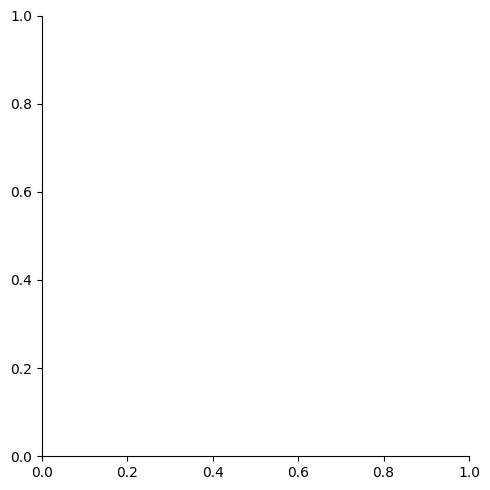

In [25]:
# As there are some missing Values in Age Column We are unable to plot the graph.
# So at first we need to solve the problem by filling or removing null Values.
sns.displot(train['Age'][train['Survived']==1],kind="kde",Truestat="density", linewidth=2)

In [ ]:
#EDA (Exploratory Data Analysis) techniques for feature Extraction and traget value estimation.

In [26]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [31]:
# As we See Cabin has More Missing Values which Impact Model efficiency 
# So Instead of filling we need to Drop that column
train.drop('Cabin',axis=1,inplace=True)

In [32]:
#Similarly we need to drop in testing DataSet
test.drop('Cabin',axis=1,inplace=True)

In [33]:
#As we see Cabin Column is get Dropped in training Dataset
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

In [34]:
#As we See Cabin Column is get dropped in testing Dataset
test.isnull().sum()

PassengerId     0
Pclass          0
Name            0
Sex             0
Age            86
SibSp           0
Parch           0
Ticket          0
Fare            1
Embarked        0
dtype: int64

In [35]:
#As in Training DataSet there are 2 missing values for Embarked.
#let's fill it with mean of the values
train.groupby(['Embarked'])['Survived'].mean()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

In [37]:
#Filled the missing Value which has the highest mean
train['Embarked'] = train['Embarked'].fillna('C')

In [ ]:
#We need to keep Embarked Column, 
#Because based on the values there is a lot of bias and more chance in survival rate.
#so there is an indirect relation.

In [38]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
dtype: int64

In [39]:
#Similarly we need to Sill the fare price in testing DataSet
test.isnull().sum()

PassengerId     0
Pclass          0
Name            0
Sex             0
Age            86
SibSp           0
Parch           0
Ticket          0
Fare            1
Embarked        0
dtype: int64

C:\Users\KATHUROJI KALYAN\AppData\Local\Temp\ipykernel_29540\2626582821.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Fare'][train['Survived']==0])
C:\Users\KATHUROJI KALYAN\AppData\Local\Temp\ipykernel_29540\2626582821.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Fare

<Axes: xlabel='Fare', ylabel='Density'>

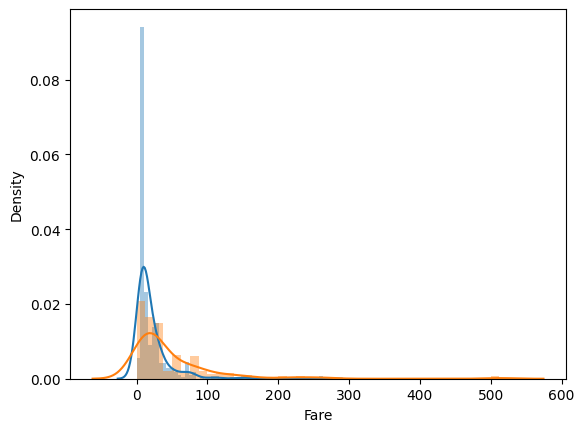

In [72]:
sns.distplot(train['Fare'][train['Survived']==0])
sns.distplot(train['Fare'][train['Survived']==1])

In [44]:
#According to our Analysis High Fare people has survived the most.
#So let's fill null values with the average of those values.
train.groupby(['Fare'])['Survived'].mean()

Fare
0.0000      0.066667
4.0125      0.000000
5.0000      0.000000
6.2375      0.000000
6.4375      0.000000
              ...   
227.5250    0.750000
247.5208    0.500000
262.3750    1.000000
263.0000    0.500000
512.3292    1.000000
Name: Survived, Length: 248, dtype: float64

In [49]:
k = (512.3292 + 262.3750)/2
test['Fare'] = test['Fare'].fillna(k)

In [50]:
test.isnull().sum()

PassengerId     0
Pclass          0
Name            0
Sex             0
Age            86
SibSp           0
Parch           0
Ticket          0
Fare            0
Embarked        0
dtype: int64

In [51]:
#As the data was unreliable on Ticket column So we can drop this column.
#Beacuse this ticket is unique and based on it we cannot predict how come he/she is survived.
train.groupby(['Ticket'])['Survived'].mean()

Ticket
110152         1.000000
110413         0.666667
110465         0.000000
110564         1.000000
110813         1.000000
                 ...   
W./C. 6608     0.000000
W./C. 6609     0.000000
W.E.P. 5734    0.000000
W/C 14208      0.000000
WE/P 5735      0.500000
Name: Survived, Length: 681, dtype: float64

In [52]:
train.drop('Ticket',axis=1,inplace=True)

In [53]:
test.drop('Ticket',axis=1,inplace=True)

In [57]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Fare             0
Embarked         0
dtype: int64

In [56]:
test.isnull().sum()

PassengerId     0
Pclass          0
Name            0
Sex             0
Age            86
SibSp           0
Parch           0
Fare            0
Embarked        0
dtype: int64

In [59]:
#AS PassengerId is also Unique which is similar to Ticket column.
#Due to which we are unable predict based on this column.
train.drop('PassengerId',axis=1,inplace=True)

In [60]:
test.drop('PassengerId',axis=1,inplace=True)

In [65]:
print(train.isnull().sum())
print("--------------------")
print(test.isnull().sum())

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      0
dtype: int64
--------------------
Pclass       0
Name         0
Sex          0
Age         86
SibSp        0
Parch        0
Fare         0
Embarked     0
dtype: int64


In [67]:
#There is a Direct Relation between Pclass and Survived.
train.groupby(['Pclass'])['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [68]:
#As there is a Name column which has no role in predicting the values
#We gonna drop that column
train.drop('Name',axis=1,inplace=True)


In [69]:
test.drop('Name',axis=1,inplace=True)

In [70]:
# The Sex Column also directly relates to the Prediction.
train.groupby(['Sex'])['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

C:\Users\KATHUROJI KALYAN\AppData\Local\Temp\ipykernel_29540\3826302481.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Age'][train['Survived']==0])
C:\Users\KATHUROJI KALYAN\AppData\Local\Temp\ipykernel_29540\3826302481.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Age']

<Axes: xlabel='Age', ylabel='Density'>

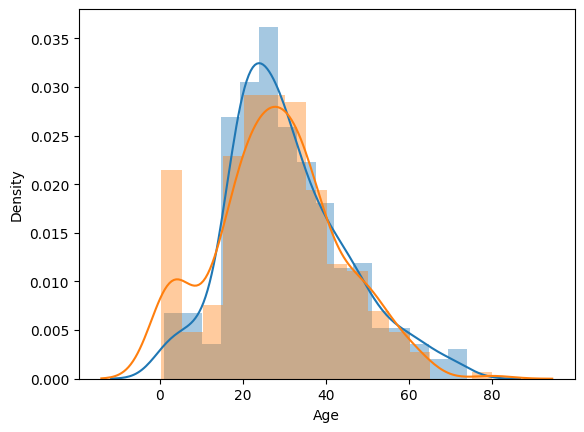

In [71]:
sns.distplot(train['Age'][train['Survived']==0])
sns.distplot(train['Age'][train['Survived']==1])

In [ ]:
# By Above Graph we can Predict that more survived people are from lower age People and old age people 
# So there is Some Sort of relation for prediction Purposes.
# So we need to handle the Data.
# One of the Methodology to fill the missing data is to use Normalization Concept by observing the above Graph Carefully.

In [73]:
train.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      0
dtype: int64

In [74]:
# NORMALIZATION METHOD TO FILL MISSING DATA IN AGE COLUMN.
train_Age = np.random.randint(train['Age'].mean()-train['Age'].std(), train['Age'].mean()+train['Age'].std(), 177)

In [75]:
test.isnull().sum()

Pclass       0
Sex          0
Age         86
SibSp        0
Parch        0
Fare         0
Embarked     0
dtype: int64

In [76]:
test_Age = np.random.randint(test['Age'].mean()-test['Age'].std(), test['Age'].mean()+test['Age'].std(), 86)

In [77]:
train['Age'][train['Age'].isnull()] = train_Age
test['Age'][test['Age'].isnull()] = test_Age

C:\Users\KATHUROJI KALYAN\AppData\Local\Temp\ipykernel_29540\3703387878.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  train['Age'][train['Age'].isnull()] = train_Age
C:\Users\KATHUROJI KALYAN\AppData\Local\Temp\ipykernel_29540\37033878

In [78]:
print(train.isnull().sum())
print("--------------------")
print(test.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64
--------------------
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [79]:
# Combining Parch and SibSp columns into a single column 
train['Family'] = train['SibSp'] + train['Parch'] + 1
test['Family'] = test['SibSp'] + test['Parch'] + 1

In [80]:
train['Family'].value_counts()

Family
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

In [81]:
# Now let's see whether this filed is required or not
train.groupby(['Family'])['Survived'].mean()

Family
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

In [ ]:
# As from the above Observation we can see that there is some sort of Dependence.
# So we need to Convert them into a Categorical Variable 

In [82]:
def cal(num):
  if num==1:
    return "Alone"
  elif num>1 and num<5:
    return "Medium"
  else:
    return "Large"

In [83]:
train['Family_Size'] = train['Family'].apply(cal)

In [84]:
train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Family,Family_Size
0,0,3,male,22.0,1,0,7.2500,S,2,Medium
1,1,1,female,38.0,1,0,71.2833,C,2,Medium
2,1,3,female,26.0,0,0,7.9250,S,1,Alone
3,1,1,female,35.0,1,0,53.1000,S,2,Medium
4,0,3,male,35.0,0,0,8.0500,S,1,Alone


In [85]:
test['Family_Size'] = test['Family'].apply(cal)

In [86]:
test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Family,Family_Size
0,3,male,34.5,0,0,7.8292,Q,1,Alone
1,3,female,47.0,1,0,7.0000,S,2,Medium
2,2,male,62.0,0,0,9.6875,Q,1,Alone
3,3,male,27.0,0,0,8.6625,S,1,Alone
4,3,female,22.0,1,1,12.2875,S,3,Medium


In [88]:
# As we have caluculated family_size it's time to drop SibSp, Parch and Family col
train.drop(columns=['SibSp','Parch','Family'],inplace=True)
test.drop(columns=['SibSp','Parch','Family'],inplace=True)

In [89]:
print(train.shape)
print(test.shape)

(891, 7)
(418, 6)


In [ ]:
# Now Our Data is ready let's make it further more Clear
# where some part of our Data is a categorical One 
# So we need to make them into numerical one, as Machine understands Numerical Data only.

In [90]:
# LABEL ENCODING METHOD USED FOR CONVERSION
train = pd.get_dummies(train, columns=['Pclass','Sex','Embarked','Family_Size'],drop_first=True,dtype=int)
test = pd.get_dummies(test, columns=['Pclass','Sex','Embarked','Family_Size'],drop_first=True,dtype=int)

In [91]:
print(train.shape)
print(test.shape)

(891, 10)
(418, 9)


In [92]:
train

,Survived,Age,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,Family_Size_Large,Family_Size_Medium
0,0,22.0,7.2500,0,1,1,0,1,0,1
1,1,38.0,71.2833,0,0,0,0,0,0,1
2,1,26.0,7.9250,0,1,0,0,1,0,0
3,1,35.0,53.1000,0,0,0,0,1,0,1
4,0,35.0,8.0500,0,1,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
886,0,27.0,13.0000,1,0,1,0,1,0,0
887,1,19.0,30.0000,0,0,0,0,1,0,0
888,0,20.0,23.4500,0,1,0,0,1,0,1
889,1,26.0,30.0000,0,0,1,0,0,0,0


In [93]:
X = train.iloc[:,1:].values
Y = train.iloc[:,0].values

In [ ]:
# OUR DATA IS READY NOW IT'S TIME TO TRAIN THE MODEL BASED ON THIS DATA.

In [94]:
#Training Testing and Spliting the model
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.3,random_state=7)

In [96]:
#Using LogisticRegression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,Y_train)
Y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy Score:",accuracy_score(Y_test,Y_pred))

Accuracy Score: 0.7611940298507462


C:\Users\KATHUROJI KALYAN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [97]:
#Confusion Matrix
from sklearn.metrics import accuracy_score,confusion_matrix
confusion_mat = confusion_matrix(Y_test,Y_pred)
print(confusion_mat)

[[134  22]
 [ 42  70]]


In [98]:
#Using Support Vector
from sklearn.svm import SVC
model1 = SVC()
model1.fit(X_train,Y_train)

pred_y = model1.predict(X_test)

from sklearn.metrics import accuracy_score
print("Acc=",accuracy_score(Y_test,pred_y))

Acc= 0.6567164179104478


In [99]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
confusion_mat = confusion_matrix(Y_test,pred_y)
print(confusion_mat)
print(classification_report(Y_test,pred_y))

[[149   7]
 [ 85  27]]
              precision    recall  f1-score   support

           0       0.64      0.96      0.76       156
           1       0.79      0.24      0.37       112

    accuracy                           0.66       268
   macro avg       0.72      0.60      0.57       268
weighted avg       0.70      0.66      0.60       268



In [100]:
#Using KNN Neighbors
from sklearn.neighbors import KNeighborsClassifier
model2 = KNeighborsClassifier(n_neighbors=5)
model2.fit(X_train,Y_train)
y_pred2 = model2.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy Score:",accuracy_score(Y_test,y_pred2))

Accuracy Score: 0.6305970149253731


In [102]:
#Using GaussianNB
from sklearn.naive_bayes import GaussianNB
model3 = GaussianNB()
model3.fit(X_train,Y_train)
y_pred3 = model3.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy Score:",accuracy_score(Y_test,y_pred3))

Accuracy Score: 0.7723880597014925


In [103]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
confusion_mat = confusion_matrix(Y_test,y_pred2)
print(confusion_mat)
print(classification_report(Y_test,y_pred3))

[[121  35]
 [ 64  48]]
              precision    recall  f1-score   support

           0       0.77      0.87      0.82       156
           1       0.77      0.64      0.70       112

    accuracy                           0.77       268
   macro avg       0.77      0.75      0.76       268
weighted avg       0.77      0.77      0.77       268



In [104]:
#Using Decision Tree
from sklearn.tree import DecisionTreeClassifier
model4 = DecisionTreeClassifier(criterion='entropy',random_state=7)
model4.fit(X_train,Y_train)
y_pred4 = model4.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy Score:",accuracy_score(Y_test,y_pred4))

Accuracy Score: 0.753731343283582


In [105]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
confusion_mat = confusion_matrix(Y_test,y_pred4)
print(confusion_mat)
print(classification_report(Y_test,y_pred4))

[[129  27]
 [ 39  73]]
              precision    recall  f1-score   support

           0       0.77      0.83      0.80       156
           1       0.73      0.65      0.69       112

    accuracy                           0.75       268
   macro avg       0.75      0.74      0.74       268
weighted avg       0.75      0.75      0.75       268



In [106]:
results = pd.DataFrame({
    'Model': ['Logistic Regression','Support Vector Machines', 'Naive Bayes','KNN' ,'Decision Tree'],
    'Score': [0.75,0.66,0.76,0.66,0.74]})

result_df = results.sort_values(by='Score', ascending=False)
result_df = result_df.set_index('Score')
result_df.head(9)

,Model
Score,
0.76,Naive Bayes
0.75,Logistic Regression
0.74,Decision Tree
0.66,Support Vector Machines
0.66,KNN


In [107]:
#Hence I will use Naive Bayes algorithms for training my model.